In [40]:
import jupyter_black
import torch
import torchvision
import os
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

jupyter_black.load()

In [2]:
device = "mps" if torch.backends.mps.is_available() else "CPU"
device

'mps'

## Getting the data for health/disease detection

In [3]:
# import kagglehub

# path = kagglehub.dataset_download("andresmgs/plantdec")
# print("Path to dataset files:", path)

In [4]:
# import shutil

# shutil.copytree(path, "Plant_project", dirs_exist_ok=True)
# print("Data successfully copied to your working folder!")

### fixing the data 

In [5]:
class CustomPlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder (e.g., 'Plant_project_data/train')
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"

        # List all image files sorted so they align correctly
        self.image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Get image path and load it
        img_name = self.image_files[idx]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        # 2. Get corresponding label file path
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name

        # 3. Read the class ID from the label file (YOLO format: class_id x_center y_center width height)
        # We take the first integer on the first line as the classification label
        label = 0  # Default fallback
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                if first_line:
                    label = int(first_line[0])  # Grab the class ID

        # 4. Apply any transformations
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [6]:
data_transform = transforms.Compose(
    [
        transforms.Resize(size=(64, 64)),
        transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip left/right
        transforms.RandomRotation(degrees=15),  # Randomly rotate by up to 15 degrees
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
    ]
)

In [7]:
base_data_path = Path("Plant_project_data")

# 2. Append the subfolders
train_dir = base_data_path / "train"
valid_dir = base_data_path / "valid"
test_dir = base_data_path / "test"

doc_train_data = CustomPlantDataset(
    root_dir="Plant_project_data/train", transform=data_transform
)
doc_valid_data = CustomPlantDataset(
    root_dir="Plant_project_data/valid", transform=data_transform
)
doc_test_data = CustomPlantDataset(
    root_dir="Plant_project_data/test", transform=data_transform
)

In [8]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=doc_train_data, batch_size=BATCH_SIZE, shuffle=True
)
valid_dataloader = DataLoader(
    dataset=doc_valid_data, batch_size=BATCH_SIZE, shuffle=False
)
test_dataloader = DataLoader(
    dataset=doc_test_data, batch_size=BATCH_SIZE, shuffle=False
)

## Getting the data for species identification

In [9]:
# os.environ["KAGGLEHUB_CACHE"] = str(Path("").absolute() / "leafsnap_data")

# 2. Run the download (it will go straight into the folder above)
# path = kagglehub.dataset_download("vandat2601/leafsnap-processed")
# print("Downloaded straight to:", path)

# 3. See what folders are inside it
# print("\nContents of your local folder:")
# print(os.listdir(path))
!pip install tqdm

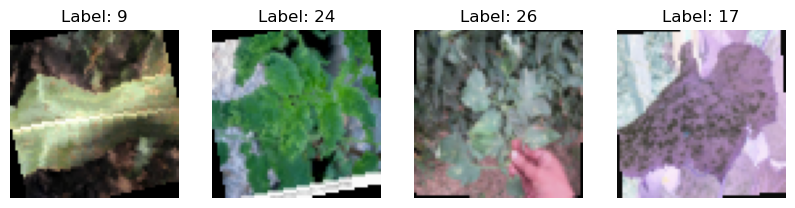

In [10]:
images, labels = next(iter(train_dataloader))

# 2. Set up a grid to plot
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)

    # PyTorch images are [Channels, Height, Width], but matplotlib needs [Height, Width, Channels]
    # We use .permute() to swap the dimensions
    img = images[i].permute(1, 2, 0).numpy()

    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()

In [11]:
class PlantHealthClassifierV0(nn.Module):
    """
    Model architecture replicating TinyVGG.
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_0 = PlantHealthClassifierV0(input_shape=3, hidden_units=20, output_shape=38).to(
    device
)

In [12]:
def train_test_step(
    model: nn.Module, train_dataloader, test_dataloader, loss_fn, optimizer, device
):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(tqdm(train_dataloader, desc="Batches", leave=False)):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average per batch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # evalualting
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for (
            batch,
            (X, y),
        ) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        print(
            f"the train loss is {train_loss}, the training accuracy, {train_acc} the test loss, {test_loss} the test accuracy, {test_acc}"
        )
        return train_loss, train_acc, test_loss, test_acc

# Training the model for health/disease detection

In [13]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
train_test_step(model_0, train_dataloader, test_dataloader, loss_fn, optimizer, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.576913429844764, the training accuracy, 0.0667189366786141 the test loss, 3.527431905269623 the test accuracy, 0.046875


(3.576913429844764, 0.0667189366786141, 3.527431905269623, 0.046875)

In [14]:
def EvalModel(
    EPOCHS, train_dataloader, valid_dataloader, model, loss_fn, optimizer, device
):
    EPOCHS = EPOCHS

    # 2. Start the loop
    for epoch in tqdm(range(EPOCHS), desc="Training Progress"):

        # Call your function, passing the clean objects
        train_loss, train_acc, val_loss, val_acc = train_test_step(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=valid_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        print(
            f"Epoch:{epoch}|Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%|Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%"
        )

In [15]:
EvalModel(5, train_dataloader, valid_dataloader, model_0, loss_fn, optimizer, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.3782390702155327, the training accuracy, 0.07721027479091995 the test loss, 3.271640647541393 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 3.3782 | Train Acc: 7.72%|Val Loss: 3.2716 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2971327727840793, the training accuracy, 0.07821833930704898 the test loss, 3.248467445373535 the test accuracy, 0.0713166144200627
Epoch:1|Train Loss: 3.2971 | Train Acc: 7.82%|Val Loss: 3.2485 | Val Acc: 7.13%


...

the train loss is 3.282586009271683, the training accuracy, 0.06864172640382318 the test loss, 3.242306124080311 the test accuracy, 0.06534090909090909
Epoch:2|Train Loss: 3.2826 | Train Acc: 6.86%|Val Loss: 3.2423 | Val Acc: 6.53%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2838571879171554, the training accuracy, 0.06530017921146952 the test loss, 3.245157545263117 the test accuracy, 0.0713166144200627
Epoch:3|Train Loss: 3.2839 | Train Acc: 6.53%|Val Loss: 3.2452 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.271453880494641, the training accuracy, 0.07295400238948625 the test loss, 3.2426141608845103 the test accuracy, 0.0713166144200627
Epoch:4|Train Loss: 3.2715 | Train Acc: 7.30%|Val Loss: 3.2426 | Val Acc: 7.13%


# Improving the model
## Changing the optimizer to Adam

In [16]:
optimizer_1 = torch.optim.Adam(params=model_0.parameters(), lr=0.01)
EvalModel(5, train_dataloader, valid_dataloader, model_0, loss_fn, optimizer_1, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.6767663455778554, the training accuracy, 0.0606705495818399 the test loss, 3.2552438432520088 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 3.6768 | Train Acc: 6.07%|Val Loss: 3.2552 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.276376220487779, the training accuracy, 0.0757915173237754 the test loss, 3.2076784047213467 the test accuracy, 0.04290752351097179
Epoch:1|Train Loss: 3.2764 | Train Acc: 7.58%|Val Loss: 3.2077 | Val Acc: 4.29%


...

the train loss is 3.2674061598316317, the training accuracy, 0.07185259856630824 the test loss, 3.2163330858403985 the test accuracy, 0.056818181818181816
Epoch:2|Train Loss: 3.2674 | Train Acc: 7.19%|Val Loss: 3.2163 | Val Acc: 5.68%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2510543407932406, the training accuracy, 0.07679958183990443 the test loss, 3.1813771507956763 the test accuracy, 0.09179075235109718
Epoch:3|Train Loss: 3.2511 | Train Acc: 7.68%|Val Loss: 3.1814 | Val Acc: 9.18%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.218605168404118, the training accuracy, 0.08618951612903226 the test loss, 3.156387545845725 the test accuracy, 0.08836206896551724
Epoch:4|Train Loss: 3.2186 | Train Acc: 8.62%|Val Loss: 3.1564 | Val Acc: 8.84%


## increasing model capacity

In [17]:
model_1 = PlantHealthClassifierV0(input_shape=3, hidden_units=64, output_shape=38).to(
    device
)
optimizer_2 = torch.optim.Adam(params=model_1.parameters(), lr=0.01)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_2, device
)
EvalModel(5, train_dataloader, valid_dataloader, model_1, loss_fn, optimizer_2, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 4.350059093967561, the training accuracy, 0.06520683990442055 the test loss, 3.359197288751602 the test accuracy, 0.046875


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2922184428861065, the training accuracy, 0.07317801672640382 the test loss, 3.225397218357433 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 3.2922 | Train Acc: 7.32%|Val Loss: 3.2254 | Val Acc: 7.13%


...

the train loss is 3.274440288543701, the training accuracy, 0.07056451612903226 the test loss, 3.258765784176913 the test accuracy, 0.046042319749216305
Epoch:2|Train Loss: 3.2744 | Train Acc: 7.06%|Val Loss: 3.2588 | Val Acc: 4.60%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.285111577280106, the training accuracy, 0.055032855436081246 the test loss, 3.2618051875721323 the test accuracy, 0.0713166144200627
Epoch:3|Train Loss: 3.2851 | Train Acc: 5.50%|Val Loss: 3.2618 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.274432478412505, the training accuracy, 0.07711693548387097 the test loss, 3.228486017747359 the test accuracy, 0.0713166144200627
Epoch:4|Train Loss: 3.2744 | Train Acc: 7.71%|Val Loss: 3.2285 | Val Acc: 7.13%


## changing learning rate

In [18]:
optimizer_3 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_3, device
)
EvalModel(5, train_dataloader, valid_dataloader, model_1, loss_fn, optimizer_3, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.260204961222987, the training accuracy, 0.07730361409796895 the test loss, 3.341549903154373 the test accuracy, 0.046875


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.253891764148589, the training accuracy, 0.07730361409796895 the test loss, 3.2258078184994785 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 3.2539 | Train Acc: 7.73%|Val Loss: 3.2258 | Val Acc: 7.13%


...

the train loss is 3.2394678631136493, the training accuracy, 0.07739695340501791 the test loss, 3.2057990594343706 the test accuracy, 0.0713166144200627
Epoch:2|Train Loss: 3.2395 | Train Acc: 7.74%|Val Loss: 3.2058 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.230086907263725, the training accuracy, 0.07730361409796895 the test loss, 3.2006573893807153 the test accuracy, 0.0713166144200627
Epoch:3|Train Loss: 3.2301 | Train Acc: 7.73%|Val Loss: 3.2007 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.219940600856658, the training accuracy, 0.07991711469534049 the test loss, 3.1416373469612817 the test accuracy, 0.08042711598746081
Epoch:4|Train Loss: 3.2199 | Train Acc: 7.99%|Val Loss: 3.1416 | Val Acc: 8.04%


In [19]:
## Reassigning model
class PlantHealthClassifierV1(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),  # Added to both convs for maximum stability
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=(hidden_units * 2) * 16 * 16, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.3),  # Prevents overfitting
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_2 = PlantHealthClassifierV1(input_shape=3, hidden_units=32, output_shape=38).to(
    device
)

In [20]:
optimizer_4 = torch.optim.Adam(params=model_2.parameters(), lr=0.001)
train_test_step(
    model_2, train_dataloader, test_dataloader, loss_fn, optimizer_4, device
)
EvalModel(15, train_dataloader, valid_dataloader, model_2, loss_fn, optimizer_4, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 4.046585909781918, the training accuracy, 0.05471550179211469 the test loss, 3.3567057847976685 the test accuracy, 0.08645833333333333


Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2683136540074504, the training accuracy, 0.0823439366786141 the test loss, 3.117298863150857 the test accuracy, 0.10256661442006271
Epoch:0|Train Loss: 3.2683 | Train Acc: 8.23%|Val Loss: 3.1173 | Val Acc: 10.26%


...

the train loss is 2.992118427830358, the training accuracy, 0.12386126045400239 the test loss, 2.993282361464067 the test accuracy, 0.15115595611285265
Epoch:12|Train Loss: 2.9921 | Train Acc: 12.39%|Val Loss: 2.9933 | Val Acc: 15.12%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0043502276943577, the training accuracy, 0.12225582437275985 the test loss, 2.955924619327892 the test accuracy, 0.14831504702194356
Epoch:13|Train Loss: 3.0044 | Train Acc: 12.23%|Val Loss: 2.9559 | Val Acc: 14.83%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.9994312870887017, the training accuracy, 0.1183169056152927 the test loss, 2.9177327806299385 the test accuracy, 0.1429271159874608
Epoch:14|Train Loss: 2.9994 | Train Acc: 11.83%|Val Loss: 2.9177 | Val Acc: 14.29%


## try to make new model with LazyConv2d and increase hidden units

In [21]:
class PlantHealthClassifierV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Compresses spatial dimensions to 1x1
            nn.Flatten(),
            # FIX: Total features entering here is now just channels (hidden_units * 2)
            nn.Linear(in_features=hidden_units * 2, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.4),  # Slightly bumped up to handle 512 units
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_3 = PlantHealthClassifierV2(input_shape=3, hidden_units=128, output_shape=38).to(
    device
)

In [22]:
optimizer_5 = torch.optim.Adam(params=model_3.parameters(), lr=0.001)
train_test_step(
    model_3, train_dataloader, test_dataloader, loss_fn, optimizer_5, device
)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2866493848062333, the training accuracy, 0.0853681302270012 the test loss, 3.2225027680397034 the test accuracy, 0.07864583333333333


(3.2866493848062333,
 0.0853681302270012,
 3.2225027680397034,
 0.07864583333333333)

In [23]:
EvalModel(5, train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.1332396038116945, the training accuracy, 0.09907034050179211 the test loss, 3.034776297482577 the test accuracy, 0.1366575235109718
Epoch:0|Train Loss: 3.1332 | Train Acc: 9.91%|Val Loss: 3.0348 | Val Acc: 13.67%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0939845423544607, the training accuracy, 0.11913829151732377 the test loss, 3.062417658892545 the test accuracy, 0.13753918495297807
Epoch:1|Train Loss: 3.0940 | Train Acc: 11.91%|Val Loss: 3.0624 | Val Acc: 13.75%


...

the train loss is 3.046716632381562, the training accuracy, 0.12940561529271208 the test loss, 3.0434590469707143 the test accuracy, 0.1321512539184953
Epoch:2|Train Loss: 3.0467 | Train Acc: 12.94%|Val Loss: 3.0435 | Val Acc: 13.22%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0437348465765677, the training accuracy, 0.1166181302270012 the test loss, 3.0669130195270884 the test accuracy, 0.14831504702194356
Epoch:3|Train Loss: 3.0437 | Train Acc: 11.66%|Val Loss: 3.0669 | Val Acc: 14.83%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.028803017831618, the training accuracy, 0.12748282556750298 the test loss, 3.0197008739818227 the test accuracy, 0.14547413793103448
Epoch:4|Train Loss: 3.0288 | Train Acc: 12.75%|Val Loss: 3.0197 | Val Acc: 14.55%


## Increase epoch to 15

In [24]:
EvalModel(15, train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.9930808044249013, the training accuracy, 0.15048163082437274 the test loss, 3.003165440125899 the test accuracy, 0.14890282131661442
Epoch:0|Train Loss: 2.9931 | Train Acc: 15.05%|Val Loss: 3.0032 | Val Acc: 14.89%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.978308020099517, the training accuracy, 0.13545400238948627 the test loss, 3.0104939504103227 the test accuracy, 0.17192398119122257
Epoch:1|Train Loss: 2.9783 | Train Acc: 13.55%|Val Loss: 3.0105 | Val Acc: 17.19%


...

the train loss is 2.6909688365074897, the training accuracy, 0.21720056750298686 the test loss, 2.8684663122350518 the test accuracy, 0.20826802507836992
Epoch:12|Train Loss: 2.6910 | Train Acc: 21.72%|Val Loss: 2.8685 | Val Acc: 20.83%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.6615276029033046, the training accuracy, 0.21972072879330945 the test loss, 2.82968393239108 the test accuracy, 0.19406347962382445
Epoch:13|Train Loss: 2.6615 | Train Acc: 21.97%|Val Loss: 2.8297 | Val Acc: 19.41%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.624220367400877, the training accuracy, 0.22819593787335724 the test loss, 2.869572574442083 the test accuracy, 0.24725705329153608
Epoch:14|Train Loss: 2.6242 | Train Acc: 22.82%|Val Loss: 2.8696 | Val Acc: 24.73%


## Increase epoch to 40

In [24]:
EvalModel(40,train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.626273209048856, the training accuracy, 0.2193100358422939 the test loss, 3.0356465686451304 the test accuracy, 0.17163009404388715
Epoch:0|Train Loss: 2.6263 | Train Acc: 21.93%|Val Loss: 3.0356 | Val Acc: 17.16%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.5778531874379804, the training accuracy, 0.24208482676224613 the test loss, 2.8992824120955034 the test accuracy, 0.20405564263322884
Epoch:1|Train Loss: 2.5779 | Train Acc: 24.21%|Val Loss: 2.8993 | Val Acc: 20.41%


...

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.192518303471227, the training accuracy, 0.34468339307048984 the test loss, 2.6616273576563056 the test accuracy, 0.29094827586206895
Epoch:21|Train Loss: 2.1925 | Train Acc: 34.47%|Val Loss: 2.6616 | Val Acc: 29.09%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

KeyboardInterrupt: 

KeyboardInterrupt: 

In [ ]:
MODEL_NAME = "best_model_plant_disease_40_epochs.pth"
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

## Changing my approach to 3 class at a time
My model accuracy is not reducing, so I will use 3 classes at a time. Once the accuracy for 3 classes is above 95%, I will move on. 

In [25]:
class CustomPlantDatasetV1(Dataset):
    def __init__(self, root_dir, transform=None, target_classes=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder
            transform (callable, optional): Transform to be applied on a sample.
            target_classes (list, optional): List of allowed class IDs (e.g., [0, 1, 2])
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"
        self.transform = transform

        all_image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )

        # Filter files if taget_classes is provided
        self.image_files = []
        if target_classes is not None:
            for img_name in all_image_files:
                label_name = img_name.rsplit(".", 1)[0] + ".txt"
                label_path = self.labels_dir / label_name

                if label_path.exists() and os.path.getsize(label_path) > 0:
                    with open(label_path, "r") as f:
                        first_line = f.readline().strip().split()
                        if first_line:
                            if int(first_line[0]) in target_classes:
                                self.image_files.append(img_name)
        else:
            self.image_files = all_image_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        img_name = self.image_files[index]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name
        label = 0
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                label = int(first_line[0])
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

ERROR! Session/line number was not unique in database. History logging moved to new session 15


In [26]:
sample_labels_dir = Path("Plant_project_data/train/labels")
found_classes = set()

# Scan the first 50 label files to see what class numbers exist
for label_file in list(sample_labels_dir.glob("*.txt"))[:50]:
    if label_file.stat().st_size > 0:
        with open(label_file, "r") as f:
            first_line = f.readline().strip().split()
            if first_line:
                found_classes.add(int(first_line[0]))

print(f"Actual Class IDs found in your dataset samples: {sorted(list(found_classes))}")

Actual Class IDs found in your dataset samples: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 29]


In [27]:
train_3_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/train",
    transform=data_transform,
    target_classes=[0, 1, 2],
)
vaild_3_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/valid",
    transform=data_transform,
    target_classes=[0, 1, 2],
)
print(f"Number of training images for 3 classes: {len(train_3_class_data)}")
print(f"Number of validation images for 3 classes: {len(vaild_3_class_data)}")

Number of training images for 3 classes: 202
Number of validation images for 3 classes: 41


In [28]:
train_3_class_dataloader = DataLoader(train_3_class_data, batch_size=32, shuffle=True)
valid_3_class_dataloader = DataLoader(vaild_3_class_data, batch_size=32, shuffle=False)

In [29]:
train_test_step(
    model=model_3,
    train_dataloader=train_3_class_dataloader,
    test_dataloader=valid_3_class_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_5,
    device=device,
)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 2.182249511991228, the training accuracy, 0.3580357142857143 the test loss, 1.83478182554245 the test accuracy, 0.5121527777777778


(2.182249511991228, 0.3580357142857143, 1.83478182554245, 0.5121527777777778)

In [30]:
EvalModel(
    5,  # EPOCHS
    train_3_class_dataloader,  # train_dataloader
    valid_3_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 1.0481557760919844, the training accuracy, 0.775 the test loss, 0.971527636051178 the test accuracy, 0.6545138888888888
Epoch:0|Train Loss: 1.0482 | Train Acc: 77.50%|Val Loss: 0.9715 | Val Acc: 65.45%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.5502523822443826, the training accuracy, 0.7982142857142858 the test loss, 0.8626793622970581 the test accuracy, 0.7100694444444444
Epoch:1|Train Loss: 0.5503 | Train Acc: 79.82%|Val Loss: 0.8627 | Val Acc: 71.01%


...

the train loss is 0.5903604796954564, the training accuracy, 0.78125 the test loss, 0.7811484932899475 the test accuracy, 0.7170138888888888
Epoch:2|Train Loss: 0.5904 | Train Acc: 78.12%|Val Loss: 0.7811 | Val Acc: 71.70%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.5310383141040802, the training accuracy, 0.7687499999999999 the test loss, 0.6793975532054901 the test accuracy, 0.7170138888888888
Epoch:3|Train Loss: 0.5310 | Train Acc: 76.88%|Val Loss: 0.6794 | Val Acc: 71.70%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.4977325626782009, the training accuracy, 0.8053571428571429 the test loss, 0.8094672858715057 the test accuracy, 0.6458333333333333
Epoch:4|Train Loss: 0.4977 | Train Acc: 80.54%|Val Loss: 0.8095 | Val Acc: 64.58%


In [31]:
EvalModel(
    15,  # EPOCHS
    train_3_class_dataloader,  # train_dataloader
    valid_3_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.3964808242661612, the training accuracy, 0.8285714285714285 the test loss, 1.0573051869869232 the test accuracy, 0.6302083333333333
Epoch:0|Train Loss: 0.3965 | Train Acc: 82.86%|Val Loss: 1.0573 | Val Acc: 63.02%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.4452924770968301, the training accuracy, 0.8008928571428572 the test loss, 0.8347828090190887 the test accuracy, 0.6614583333333333
Epoch:1|Train Loss: 0.4453 | Train Acc: 80.09%|Val Loss: 0.8348 | Val Acc: 66.15%


...

the train loss is 0.26713456426348003, the training accuracy, 0.8875000000000001 the test loss, 0.8080745935440063 the test accuracy, 0.6458333333333333
Epoch:12|Train Loss: 0.2671 | Train Acc: 88.75%|Val Loss: 0.8081 | Val Acc: 64.58%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.28429487879787174, the training accuracy, 0.8794642857142857 the test loss, 0.9707295894622803 the test accuracy, 0.7482638888888888
Epoch:13|Train Loss: 0.2843 | Train Acc: 87.95%|Val Loss: 0.9707 | Val Acc: 74.83%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.2317396742956979, the training accuracy, 0.9187500000000001 the test loss, 1.498655915260315 the test accuracy, 0.5520833333333333
Epoch:14|Train Loss: 0.2317 | Train Acc: 91.88%|Val Loss: 1.4987 | Val Acc: 55.21%


In [41]:
MODEL_NAME = "best_model_plant_disease_3_class.pth"
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/best_model_plant_disease_3_class.pth


## Increasing 13 class

In [34]:
train_13_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/train",
    transform=data_transform,
    target_classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
)
vaild_13_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/valid",
    transform=data_transform,
    target_classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
)
print(f"Number of training images for 13 classes: {len(train_13_class_data)}")
print(f"Number of validation images for 13 classes: {len(vaild_13_class_data)}")

Number of training images for 13 classes: 911
Number of validation images for 13 classes: 148


In [37]:
train_13_class_dataloader = DataLoader(train_13_class_data, batch_size=32, shuffle=True)
valid_13_class_dataloader = DataLoader(
    vaild_13_class_data, batch_size=32, shuffle=False
)

In [38]:
train_test_step(
    model=model_3,
    train_dataloader=train_13_class_dataloader,
    test_dataloader=valid_13_class_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_5,
    device=device,
)

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

the train loss is 3.0593327859352373, the training accuracy, 0.2831896551724138 the test loss, 1.929078221321106 the test accuracy, 0.4425


(3.0593327859352373, 0.2831896551724138, 1.929078221321106, 0.4425)

In [39]:
EvalModel(
    30,  # EPOCHS
    doc_train_data,  # train_dataloader
    valid_13_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

Training Progress:   0%|          | 0/30 [00:00<?, ?it/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

the train loss is 1.6792436303763554, the training accuracy, 0.45926724137931035 the test loss, 1.8901906728744506 the test accuracy, 0.3175
Epoch:0|Train Loss: 1.6792 | Train Acc: 45.93%|Val Loss: 1.8902 | Val Acc: 31.75%


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

the train loss is 1.4872126908137882, the training accuracy, 0.4783764367816092 the test loss, 1.73581223487854 the test accuracy, 0.41624999999999995
Epoch:1|Train Loss: 1.4872 | Train Acc: 47.84%|Val Loss: 1.7358 | Val Acc: 41.62%


...

the train loss is 0.976951525129121, the training accuracy, 0.6492097701149425 the test loss, 1.7820334434509277 the test accuracy, 0.46375
Epoch:27|Train Loss: 0.9770 | Train Acc: 64.92%|Val Loss: 1.7820 | Val Acc: 46.38%


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

the train loss is 0.9789401251694252, the training accuracy, 0.669683908045977 the test loss, 1.9068400144577027 the test accuracy, 0.46624999999999994
Epoch:28|Train Loss: 0.9789 | Train Acc: 66.97%|Val Loss: 1.9068 | Val Acc: 46.62%


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

the train loss is 1.0152159415442368, the training accuracy, 0.6484913793103447 the test loss, 1.747607445716858 the test accuracy, 0.48875
Epoch:29|Train Loss: 1.0152 | Train Acc: 64.85%|Val Loss: 1.7476 | Val Acc: 48.88%


## Changing to transfer learning as training a model from scarch is not working

In [57]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model_efficientnet = torchvision.models.efficientnet_b0(weights=weights).to(device)

# 2. Freeze the core feature extractor layers (FIXED: added the 's')
for param in model_efficientnet.features.parameters():
    param.require_grad = False

# 3. Swap out the classifier head for your FULL 38 classes
model_efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True), nn.Linear(in_features=1280, out_features=38)
).to(device)

In [58]:
from torchvision import transforms

IMAGE_SIZE = (224, 224)

normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)

train_transforms = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        normalization,  # 👈 Add this
    ]
)

valid_transforms = transforms.Compose(
    [transforms.Resize(IMAGE_SIZE), transforms.ToTensor(), normalization]  # 👈 Add this
)

In [ ]:
optimizer_eff = torch.optim.Adam(
    params=model_efficientnet.classifier.parameters(), lr=0.001
)
doc_train_dataloader = DataLoader(doc_train_data, batch_size=32, shuffle=True)
doc_valid_dataloader = DataLoader(doc_valid_data, batch_size=32, shuffle=False)
train_test_step(
    model=model_efficientnet,
    train_dataloader=doc_train_dataloader,
    test_dataloader=doc_valid_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_eff,
    device=device,
)
EvalModel(
    EPOCHS=10,
    train_dataloader=doc_train_dataloader,  # Make sure this matches your 13-class loader name!
    valid_dataloader=doc_valid_dataloader,
    model=model_efficientnet,
    loss_fn=loss_fn,
    optimizer=optimizer_eff,
    device=device,
)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]